# BioEng 142 Final Project

This notebook contains my full final-project pipeline. Sections 1-6 cover model implementation, regularization strategy, hyperparameter tuning, and training the final tuned model. Sections 7-9 contain the implementation and results of the multiple training runs and K-fold cross validation. Section 10 contains a breif discussions on the implications of said results.

##1. Import Dependencies

Run the following cell to install the necessary dependencies.

*Note*: *torchani must be pinned to version 2.2.3 for this notebook*

In [1]:
import torch
import torch.nn as nn
%pip uninstall torchani -y
%pip install torchani==2.2.3
%pip install optuna scikit-learn
import torchani
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import optuna
import os
import glob
import tarfile
import shutil
from google.colab import drive
import copy
from tqdm.auto import tqdm
drive.mount('/content/drive')
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# Optimize for A100 (Ampere) by enabling TF32
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision('high')   # TF32 on A100
except AttributeError:
    pass

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Found existing installation: torchani 2.2.3
Uninstalling torchani-2.2.3:
  Successfully uninstalled torchani-2.2.3
  Using cached torchani-2.2.3-py3-none-any.whl.metadata (6.0 kB)
Using cached torchani-2.2.3-py3-none-any.whl (10.9 MB)


/usr/local/lib/python3.12/dist-packages/torchani/aev.py:16: UserWarning: cuaev not installed
  warnings.warn("cuaev not installed")
/usr/local/lib/python3.12/dist-packages/torchani/__init__.py:55: UserWarning: Dependency not satisfied, torchani.ase will not be available
  warnings.warn("Dependency not satisfied, torchani.ase will not be available")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


##2. Training / Evaluation Loop

Run the following cell to declare the training and evaluation loops for our model.

In [2]:
HARTREE2KCALMOL = 627.5094738898777
class ANITrainer:
    """
    Patched trainer:
      • proper patience-based early stopping with deep-copied best weights
      • BF16 autocast on A100 (no GradScaler needed)
      • set_to_none grads, non_blocking H2D copies, on-GPU loss accumulation
      • model.eval() during validation, restored afterwards
      • optional torch.compile
    """

    def __init__(self, model, batch_size, learning_rate, epoch, l2,
                 verbose=False, patience=20,
                 use_amp=True, amp_dtype=torch.bfloat16,
                 compile_model=False):
        self.model = model
        self.verbose = verbose

        if compile_model and hasattr(torch, "compile"):
            try:
                self.model = torch.compile(self.model)
                if verbose:
                    print("Model compiled with torch.compile()")
            except Exception as e:
                if verbose:
                    print(f"torch.compile failed ({e}); continuing without it.")

        if verbose:
            n = sum(p.numel() for p in self.model.parameters())
            print(f"{model.__class__.__name__} - Number of parameters: {n}")

        self.batch_size = batch_size
        self.optimizer  = torch.optim.Adam(self.model.parameters(),
                                           lr=learning_rate, weight_decay=l2)
        self.epoch     = epoch
        self.patience  = patience
        self.use_amp   = use_amp and torch.cuda.is_available()
        self.amp_dtype = amp_dtype

    # -- shared forward path used by both train and evaluate --
    def _forward_loss(self, batch, loss_func):
        species       = batch['species'].to(device, non_blocking=True)
        coordinates   = batch['coordinates'].float().to(device, non_blocking=True)
        true_energies = batch['energies'].float().to(device, non_blocking=True)

        if species.dim() == 3:
            b1, b2, a = species.shape
            species = species.view(b1 * b2, a)
            coordinates = coordinates.view(b1 * b2, a, 3)
            true_energies = true_energies.view(b1 * b2)

        num_atoms     = (species >= 0).sum(dim=1, dtype=true_energies.dtype)

        if self.use_amp:
            with torch.autocast(device_type='cuda', dtype=self.amp_dtype):
                pred_energies = self.model((species, coordinates)).energies
            pred_energies = pred_energies.float()       # loss always in FP32
        else:
            pred_energies = self.model((species, coordinates)).energies

        batch_loss = loss_func(pred_energies / num_atoms,
                               true_energies / num_atoms)
        return batch_loss, pred_energies, true_energies

    def train(self, train_data, val_data, early_stop=True,
              draw_curve=True, trial=None):
        if self.verbose:
            print("Initialize training data...")
        train_loader = train_data.collate(self.batch_size).cache()

        loss_func = nn.MSELoss()

        train_loss_list, val_loss_list = [], []
        lowest_val_loss = np.inf
        epochs_no_improve = 0
        best_weights = None
        best_epoch   = 0

        for i in tqdm(range(self.epoch), leave=True):
            self.model.train()
            # accumulate on GPU — no per-batch host sync
            train_loss_sum = torch.zeros((), device=device)

            for batch in train_loader:
                self.optimizer.zero_grad(set_to_none=True)
                batch_loss, _, true_energies = self._forward_loss(batch, loss_func)
                batch_loss.backward()
                self.optimizer.step()
                train_loss_sum += batch_loss.detach() * true_energies.size(0)

            train_epoch_loss = train_loss_sum.item()
            val_epoch_loss   = self.evaluate(val_data, draw_plot=False)

            if self.verbose:
                rmse_kcal = (val_epoch_loss ** 0.5) * HARTREE2KCALMOL
                print(f"  epoch {i+1}: val RMSE/atom = {rmse_kcal:.3f} kcal/mol/atom")

            if trial is not None:
                trial.report(val_epoch_loss, step=i)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()

            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)

            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    # deep copy! state_dict() returns live references
                    best_weights = copy.deepcopy(self.model.state_dict())
                    best_epoch = i
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= self.patience:
                        if self.verbose:
                            print(f"Early stop at epoch {i+1} "
                                  f"(no improvement for {self.patience} epochs; "
                                  f"best epoch: {best_epoch+1}, "
                                  f"val_loss={lowest_val_loss:.6g})")
                        break

        if draw_curve:
            n = len(train_loss_list)
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            ax.plot(range(n), train_loss_list, label='Train')
            ax.plot(range(n), val_loss_list,   label='Validation')
            ax.legend(); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")

        if early_stop and best_weights is not None:
            self.model.load_state_dict(best_weights)

        return train_loss_list, val_loss_list

    def evaluate(self, data, draw_plot=False):
        was_training = self.model.training
        self.model.eval()

        data_loader = data.collate(self.batch_size).cache()
        loss_func   = nn.MSELoss()
        total_loss_sum = torch.zeros((), device=device)

        if draw_plot:
            trues, preds = [], []

        with torch.no_grad():
            for batch in data_loader:
                batch_loss, pred_e, true_e = self._forward_loss(batch, loss_func)
                total_loss_sum += batch_loss.detach() * true_e.size(0)
                if draw_plot:
                    trues.append(true_e.detach().cpu().numpy().flatten())
                    preds.append(pred_e.detach().cpu().numpy().flatten())

        total_loss = total_loss_sum.item()

        if draw_plot:
            trues = np.concatenate(trues)
            preds = np.concatenate(preds)
            mae = np.mean(np.abs(trues - preds)) * HARTREE2KCALMOL
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(trues, preds, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth"); ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim(); ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax); ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()

        if was_training:
            self.model.train()

        return total_loss

##3. Model Implementation

###3.1. ```TwoStreamNet``` Model Backbone

Since we were allowed to create our own architectures to predict I decided to implement ```TwoStreamNet```, a model which consists of two steams which are then concatenated and fed through a learned gate to a final discriminator network. The first stream is a two-layer MLP which encodes pairwise distances to be used to represent bond length. The second stream encodes the bond angle via triplets. As previously mentioned, the two streams are concatenated and fed through a learned gate which upweights informative AEV dimensions while supressing irrelevant ones. Finally, the logits get passed through a block of residual connections to maintain the training signal with one final linear layer for classification. The implementation of ```TwoStreamNet``` can be found below:

In [3]:
class TwoStreamNet(nn.Module):
    """
    Pipeline
    ----------
    AEV  ──┬── radial_stream  (first  n_radial dims) ──► proj_r ──┐
            │                                                       ├─ cat ─► SE ─► residual stack ─► output
            └── angular_stream (remaining dims)       ──► proj_a ──┘

    Parameters
    ----------
    aev_dim     : total AEV length (provided by aev_computer.aev_length)
    n_radial    : number of radial AEV elements
                  = num_species * num_radial_terms
    hidden_dim  : width of the merged hidden representation
    n_residual  : number of residual blocks after merging
    dropout     : dropout rate inside residual blocks
    """

    def __init__(
        self,
        aev_dim:    int,
        n_radial:   int,
        hidden_dim: int   = 256,
        n_residual: int   = 3,
        dropout:    float = 0.0,
    ):
        super().__init__()
        self.n_radial = n_radial
        n_angular = aev_dim - n_radial

        # Stream 1: radial features
        self.radial_stream = nn.Sequential(
            nn.Linear(n_radial, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.CELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.CELU(),
        )

        # Stream 2: angular features
        self.angular_stream = nn.Sequential(
            nn.Linear(n_angular, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.CELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.CELU(),
        )

        merged_dim = hidden_dim  # hidden_dim//2 + hidden_dim//2

        # Learned Gate
        self.se = SqueezeExcitation(merged_dim)

        # Residual stack
        self.residual_stack = nn.Sequential(*[ResidualBlock(merged_dim, dropout) for _ in range(n_residual)])

        # Output
        self.output_head = nn.Sequential(
            nn.LayerNorm(merged_dim),
            nn.CELU(),
            nn.Linear(merged_dim, 1),  # scalar atomic energy
        )

        # init Ws
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, aev: torch.Tensor) -> torch.Tensor:
        """
        aev : (N_atoms, aev_dim)  — atom-level AEV features
        returns: (N_atoms, 1)     — atomic energy contributions
        """
        # Split AEV into radial and angular parts at known boundary
        r_feat = aev[:, :self.n_radial]
        a_feat = aev[:, self.n_radial:]

        r_out = self.radial_stream(r_feat)   # (N, hidden//2)
        a_out = self.angular_stream(a_feat)  # (N, hidden//2)

        x = torch.cat([r_out, a_out], dim=-1)  # (N, hidden)
        x = self.se(x)                          # channel re-calibration
        x = self.residual_stack(x)              # deep feature extraction
        return self.output_head(x)              # (N, 1)

###3.2. Activations

Since the potential energy surface is expected to be smooth I opted to use CELU activations instead of the standard RELU variant, as unlike RELU it is both smooth and infintely differentiable.

###3.3. SqeezeExcitation Gate

In addition to the above ```TwoStreamNet``` class, I needed to implement a helper class to handle the channel re-calibration/learned gate. In order to accomplish this, I have implemented the ```SqueezeExcitation``` class which can be found below:

In [4]:
class SqueezeExcitation(nn.Module):
    """
    Channel-wise feature re-calibration.

    Learns a soft gate that up-weights informative AEV dimensions and suppresses irrelevant ones.
    Reduction ratio r=4 keeps the gating MLP lightweight.
    """
    def __init__(self, dim: int, reduction: int = 4):
        super().__init__()
        mid = max(dim // reduction, 8)
        self.gate = nn.Sequential(
            nn.Linear(dim, mid),
            nn.ReLU(),
            nn.Linear(mid, dim),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.gate(x)           # element-wise re-scaling

###3.4. Residual Connections

Similarly, I have also implementd a helper class to handle the residual blocks. Its implemtation can be found below within the ```ResidualBlock``` class:

In [5]:
class ResidualBlock(nn.Module):
    """
    Pre-activation residual block:  x -> LayerNorm -> CELU -> Linear ->
                                        LayerNorm -> CELU -> Linear -> + x
    """
    def __init__(self, dim: int, dropout: float = 0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.CELU(),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.CELU(),
            nn.Dropout(p=dropout),
            nn.Linear(dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)          # identity shortcut

###3.5. Training Wrapper

Finally, we must implement a wrapper class that will allow ```TwoStreamNet``` to be compatible with the ANI framework. Run the following cell to declare the ```TwoStreamNetAni``` class for this task:

In [6]:
# Named-tuple that mirrors torchani's output so ANITrainer works unchanged
from typing import NamedTuple
class ANIResult(NamedTuple):
    species:  torch.Tensor
    energies: torch.Tensor


class TwoStreamNetANI(nn.Module):
    """
    TorchANI-compatible wrapper around TwoStreamNet.

    Accepts the (species, coordinates) tuple produced by torchani data loaders,
    computes AEVs, feeds every real atom through TwoStreamNet,
    and sums atomic contributions to return molecule-level energies.

    Parameters
    ----------
    aev_computer : torchani.AEVComputer
        Pre-configured AEV computer (taken from ANI1x model).
    two_stream_net : TwoStreamNet
        The per-atom network.
    """

    def __init__(self, aev_computer, two_stream_net: TwoStreamNet):
        super().__init__()
        self.aev_computer = aev_computer
        self.net = two_stream_net

    def forward(self, species_coords):
        species, coords = species_coords               # (B, A), (B, A, 3)

        # compute AEVs
        _, aev = self.aev_computer(species_coords)     # torchani convention

        # apply TwoStreamNet to real atoms only
        B, A, D = aev.shape
        mask           = (species >= 0)                # (B, A)  True = real atom
        aev_flat       = aev.reshape(B * A, D)         # (B*A, D)
        mask_flat      = mask.reshape(B * A)           # (B*A,)

        real_aev           = aev_flat[mask_flat]       # (N_real, D)
        net_out            = self.net(real_aev).squeeze(-1)

        atom_energies_flat = torch.zeros(B * A, device=aev.device, dtype=net_out.dtype)
        atom_energies_flat[mask_flat] = net_out

        # sum atomic contributions per molecule
        atom_energies = atom_energies_flat.reshape(B, A)  # (B, A)
        mol_energies  = (atom_energies * mask.float()).sum(dim=1)  # (B,)

        return ANIResult(species=species, energies=mol_energies)


##4. Regularization Strategies

The purpsose of this section is to explore and justify the regularization strategies employed within the ```TwoStreamNet``` model implemented above. This section will not explore the specific hyperparamters used for said strategies, as that will be covered in section 5 (Hyperparameter Tuning).

###4.1 Data Preprocessing

####4.1.1 Self-Energy Subtraction
Given that the total energy of a molecule is dominated by single-atom contributions that provide no information about molecular reactions, it is essential to remove them for optimal training. This is because their removal drastically reduces variance of the labels the network is trying to predict, and is performed when loading the dataset.

###4.2 Activations

####4.2.1 Activation Functions
Traditional RELU activations zero out negative gradient values, in turn decreasing training stability by leading to vanishing gradients. Additionally, all RELU activations, including leaky RELU, are not differentiable at zero. Because of this, I opted to use CELU activations in my model as they do not suffer from the aforementioned problems.

####4.2.2 Activation Normalization
Given that ```TwoStreamNet``` is a dense residual network with CELU activations, it is particularly susceptible to exploding gradients. This is especially true because AEV elements have very different natural scales within the radial and angular streams. Because of this, I deciced to add ```LayerNorm``` modules before every activation, as it compensates for this by smoothing the loss landscape. The choice to add ```Layernorm``` modules before activations was intentional as it is a common design choice in residual networks.  

###4.3 Skip Connections

Skip connections help dense networks maintain a healthy training/gradient signal by allowing gradient information to flow back through the network without passing through any intermediate nonlinearities (weight layers, actiactions, etc). My initial implementation of the network involved two hidden layers per "stream", and six hidden layers in the secondary concatenated network. Given the depth of my network, I decided to insert skip connections after every two layers within the secondary network to compensate for this. Skip connections are not necessary within the initial "stream" networks because they are not suffiently deep enough.

###4.4 Training Interventions

####4.4.1 Weight Initialization
As mentioned in section 4.2.1 I chose to use CELU activations in my model. The CELU activation is approximately linear near zero, and are thus particularly effective with low yet non-zero initial weight values. After looking into some potential weight initialization strategies, I opted to implement Xavier uniform weight initialization as its linearity assumption makes it particularly effective for models with CELU activations.

####4.4.3 Early Stopping
Our given training loop impements a version of early-stopping, which restores the model's best ```state_dict``` after training has compeleted. This is a standard technique to prevent overfitting as it restores the model with the best evaluation results, and is thus justified for training the prodcution version of the ```TwoStreamNet``` model.

####4.4.5 Dropout
Dropout temporarily disables certain activations during training to force the model to learn redundant represenations, in turn preventing the co-adaptation of neurons within the network. Although dropout was disabled within the initial training of the model, it will be explored within section 5.

###4.5 Loss Computation

####4.5.1 L2 Regularization/Weight Decay
Weight decay adds a term to the loss function which discourages the network from adopting large weight values. This prevents the network from relying on single weights too much, which is beneficial since the potential energy surface is anticipated to be smooth. I did not enable weight decay in my initial training of the model, but I will explore it in section 5.

####4.5.2 Per-atom Normalization
Raw molecular energies scale with the number of atoms within the molecule. This is relevant because without normalization the training/gradient signal would be dominated by larger molecules, in turn leading to overfitting. Thus, I divided the predicted and true energies by the number of atoms within the loss function. This in turn causes the loss function's error metric to become size-invariant, solving the aforementioned problem.

##5 Hyperparameter Tuning

Given that we have access to high compute resources, I thought it would be fun to implement bayesian hyperparameter tuning instead of using a typical hyperparameter tuning strategy such as ```GridSearchCV```. The following section will provide justification for this tuning strategy and its implementation. The final model summary will be provided in the next section.

###5.1 Motivation

####5.1.1 Why Not ```GridSearchCV```?
```GridSearchCV``` evalutates every possible combination of hyperparameters in a specified grid. As a result, search time increases exponentially with the number of parameters as all configurations must be trained. Thus, ```GridSearchCV``` typically has a very small search space and is limited to a small set of hyperparameters, which may cause optimal configurations to be ignored during tuning.

####5.1.2 Bayes Rule and Bayesian Hyperparameter Tuning
Bayesian tuning is an alternalive tuning strategy that exploits Baye's rule from conditional probability to find optimal hyperparameters in a significantly more efficient manner. Baye's rule allows one to calculate the updated probability of a hypothesis (posterior) by combining prior knowledge with new evidence. Similarly, bayesian hyperparamter tuning uses a surrogate model and an acquisition funciton to predict and chose the next best hyperparameters to evaluate. In theory, this allows for the exploration of larger hyperparameter search spaces and the simultaneous tuning of additional paramters.

###5.2 Instance Setup

####5.2.1 Data Loading

The ANI-1 dataset is contained within a ```.tar.gz``` file, and thus must be extracted before dataloading. I have extracted the dataset files into a remote folder. Run the following cell to copy the dataset shards into the local runtime:

In [ ]:
# Set file paths
DRIVE_DIR = '/content/drive/MyDrive/ANI-1_release'
LOCAL_DIR = '/content/ANI-1_release_local'

# Copy shards to runtime from Drive
os.makedirs(LOCAL_DIR, exist_ok=True)
expected_shards = [f'ani_gdb_s{i:02d}.h5' for i in range(1, 9)]
for shard in expected_shards:
    src = os.path.join(DRIVE_DIR, shard)
    dst = os.path.join(LOCAL_DIR, shard)
    if not os.path.exists(dst):
        if os.path.exists(src):
            print(f"Copying {shard} from {DRIVE_DIR} to {LOCAL_DIR}...")
            shutil.copy2(src, dst)
        else:
            print(f"Warning: {shard} not found in {DRIVE_DIR}!")
    else:
        print(f"{shard} already exists in {LOCAL_DIR}.")

H5_FILES = sorted(glob.glob(os.path.join(LOCAL_DIR, 'ani_gdb_s*.h5')))
# Ensure we are training on the full dataset (Checkpoint 5+ only)
assert len(H5_FILES) == 8, f'Expected 8 shards, found {len(H5_FILES)}'
print(f'Loaded shards: {[os.path.basename(f) for f in H5_FILES]}')

ani_gdb_s01.h5 already exists in /content/ANI-1_release_local.
ani_gdb_s02.h5 already exists in /content/ANI-1_release_local.
ani_gdb_s03.h5 already exists in /content/ANI-1_release_local.
ani_gdb_s04.h5 already exists in /content/ANI-1_release_local.
ani_gdb_s05.h5 already exists in /content/ANI-1_release_local.
ani_gdb_s06.h5 already exists in /content/ANI-1_release_local.
ani_gdb_s07.h5 already exists in /content/ANI-1_release_local.
ani_gdb_s08.h5 already exists in /content/ANI-1_release_local.
Loaded shards: ['ani_gdb_s01.h5', 'ani_gdb_s02.h5', 'ani_gdb_s03.h5', 'ani_gdb_s04.h5', 'ani_gdb_s05.h5', 'ani_gdb_s06.h5', 'ani_gdb_s07.h5', 'ani_gdb_s08.h5']


Once loaded, we can begin processing the data into a standard 80/20 train-test split. Run the following cell to do so:

In [7]:
# Build dataset
LOCAL_DIR = '/content/ani_gdb_s01_to_s04.h5' # UPDATE
ani1x = torchani.models.ANI1x(periodic_table_index=False)
print("Building dataset from shards...")
dataset = (
    torchani.data.load(LOCAL_DIR, additional_properties=('energies',))
    .subtract_self_energies(ani1x.energy_shifter, ani1x.species)
    .species_to_indices(ani1x.species)
    .shuffle()
)

# Split
training, validation = dataset.split(0.8, None)

# Optional runtime performance boost: cache the post-transform tensors in RAM so
# subsequent epochs don't re-read/re-transform from disk. ANI-1 (~22M
# conformations) fits comfortably in the high-RAM A100 Colab instance.
colab = False # Set to False to avoid double collation causing CUDA OOM
if colab:
  print("Begin optimizing runtime...")
  training   = training.collate(2560).cache()
  validation = validation.collate(2560).cache()
  print("Runtime optimization complete!")

print('Data loaded and split successfully.')

/usr/local/lib/python3.12/dist-packages/torchani/resources/
Building dataset from shards...
Data loaded and split successfully.


####5.2.2 AEV Initialization

The following cell declares and instantiates the values fixed during hyperparameter tuning deried from the ANI-1x AEV computer.

In [8]:
aev_computer      = ani1x.aev_computer.to(device)
num_species       = len(ani1x.species)
num_radial_shifts = aev_computer.ShfR.numel()
n_radial          = num_species * num_radial_shifts
aev_dim           = aev_computer.aev_length

print(f'AEV dimension    : {aev_dim}')
print(f'Radial elements  : {n_radial} ({num_species} species x {num_radial_shifts} shifts)')
print(f'Angular elements : {aev_dim - n_radial}')

AEV dimension    : 384
Radial elements  : 64 (4 species x 16 shifts)
Angular elements : 320


###5.3 Tuning Implementation

####5.3.1 Tuning Config

Use the following cell to adjust the number of epochs per trial, and number of optuna trials for an experiment respectively.

In [ ]:
TUNE_EPOCHS = 20    # epochs per trial
N_TRIALS    = 5   # number of trials

####5.3.2 Objective Function

As mentioned in section 5.1.2, bayesian tuning requires an objective function to determine which hypermemters to suggest. The following cell implements an objective function for ```TwoStreamNet``` using the ```optuna``` library, which is often used for this task.

In [ ]:
def objective(trial: optuna.Trial) -> float:
    """Optuna objective: train TwoStreamNet with suggested hyperparameters
    and return the best validation loss achieved."""

    # Suggest hyperparameters
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [128, 256, 512])
    l2            = trial.suggest_float('l2_weight_decay', 0.0, 1e-3)
    hidden_dim    = trial.suggest_categorical('hidden_dim', [128, 192, 256, 320, 384])
    n_residual    = trial.suggest_int('n_residual', 2, 5)
    dropout       = trial.suggest_float('dropout', 0.0, 0.3)

    # Build model
    core_net = TwoStreamNet(
        aev_dim=aev_dim,
        n_radial=n_radial,
        hidden_dim=hidden_dim,
        n_residual=n_residual,
        dropout=dropout,
    ).to(device)
    model = TwoStreamNetANI(aev_computer, core_net).to(device)

    # Train
    trainer = ANITrainer(
        model=model,
        batch_size=batch_size,
        learning_rate=learning_rate,
        epoch=TUNE_EPOCHS,
        l2=l2,
        verbose=False,
    )

    try:
        _, val_losses = trainer.train(
            train_data=training,
            val_data=validation,
            early_stop=True,
            draw_curve=False,
            trial=trial,      # enables per-epoch median pruning
        )
    except optuna.exceptions.TrialPruned:
        raise
    finally:
        # Free GPU memory between trials
        del model, core_net, trainer
        torch.cuda.empty_cache()

    return min(val_losses)

###5.4 Tuning

Now that we have implemented an objective function for the ```TwoStreamNet``` model, we can use ```optuna``` to automatically construct a surrogate model and perform bayesian hyperparamter tuning. Run the following cell to do so:

In [ ]:
sampler = optuna.samplers.TPESampler(seed=42)
pruner  = optuna.pruners.MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=2,
    interval_steps=1,
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
    study_name='TwoStreamNet_BayesianHPT',
)

print(f'Starting Bayesian HPT: {N_TRIALS} trials x {TUNE_EPOCHS} epochs each.\n')

study.optimize(
    objective,
    n_trials=N_TRIALS,
    gc_after_trial=True,
    show_progress_bar=True,
)

Starting Bayesian HPT: 5 trials x 20 epochs each.



  0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [17:56<00:00, 53.81s/it]

100%|██████████| 20/20 [19:45<00:00, 59.26s/it]

100%|██████████| 20/20 [23:10<00:00, 69.54s/it]

100%|██████████| 20/20 [10:35<00:00, 31.77s/it]

100%|██████████| 20/20 [09:48<00:00, 29.45s/it]


###5.5 Tuning Results

Run the following cell to output the results of the experiment performed above:

In [ ]:
completed = [t for t in study.trials
             if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in study.trials
             if t.state == optuna.trial.TrialState.PRUNED]

print(f'Completed trials : {len(completed)}')
print(f'Pruned   trials  : {len(pruned)}')
print()

best = study.best_trial
print(f'Best validation loss : {best.value:.6e} Hartree\u00b2/atom')
print('Best hyperparameters :')
for k, v in best.params.items():
    print(f'  {k:<22} {v}')

Completed trials : 5
Pruned   trials  : 0

Best validation loss : 3.274058e-01 Hartree²/atom
Best hyperparameters :
  learning_rate          0.0004066563313514797
  batch_size             256
  l2_weight_decay        0.00012203823484477882
  hidden_dim             256
  n_residual             3
  dropout                0.15602040635334324


I thought it would also be useful to visualize the results of the bayesian tuning performed above. The following cell generates two figures. First, it plots how the best validation loss improved over sucessive trials (left). Next, it shows the estimated importance of each hyperparameter via an ANOVA estimator. Run the following cell to generate the aforementioned outputs.

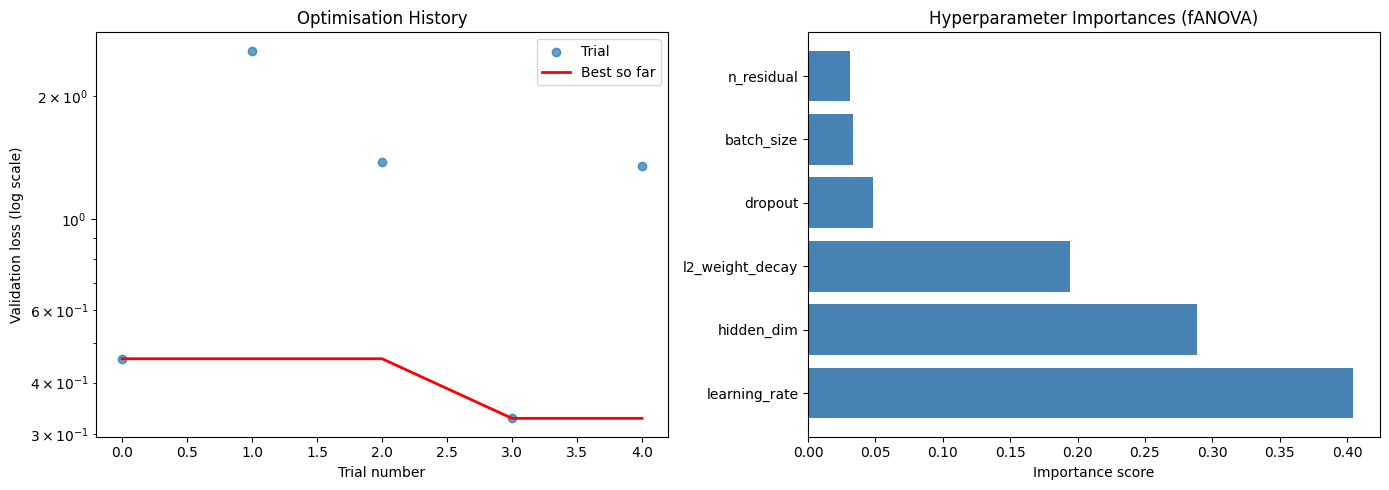

In [ ]:
completed_trials = [t for t in study.trials
                    if t.state == optuna.trial.TrialState.COMPLETE]
nums   = [t.number for t in completed_trials]
values = [t.value  for t in completed_trials]
bests  = list(np.minimum.accumulate(values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimisation history
axes[0].scatter(nums, values, alpha=0.7, label='Trial')
axes[0].plot(nums, bests, 'r-', linewidth=2, label='Best so far')
axes[0].set_yscale('log')
axes[0].set_xlabel('Trial number')
axes[0].set_ylabel('Validation loss (log scale)')
axes[0].set_title('Optimisation History')
axes[0].legend()

# Hyperparameter importances
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()),
                 color='steelblue')
    axes[1].set_xlabel('Importance score')
    axes[1].set_title('Hyperparameter Importances (fANOVA)')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Importances unavailable:\n{e}',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

Finally, I wanted to visualize the search space using a parrallel coordinate plot of completed trails. Run the following cell to generate this visualization:

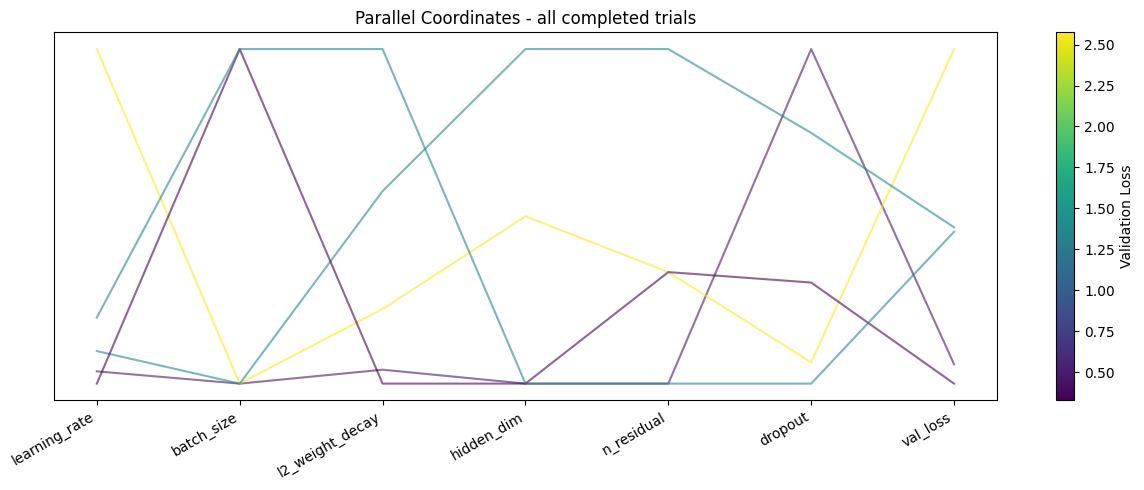

In [ ]:
# Parallel coordinate plot of completed trials
param_names = list(study.best_params.keys())
rows = []
for t in completed_trials:
    row = [t.params.get(p) for p in param_names] + [t.value]
    rows.append(row)

data = np.array(rows, dtype=float)

# Normalise each column to [0, 1] for plotting
col_min = data.min(axis=0)
col_max = data.max(axis=0)
span = col_max - col_min
span[span == 0] = 1
data_norm = (data - col_min) / span

cols = param_names + ['val_loss']
cmap = plt.cm.viridis
norm = plt.Normalize(data[:, -1].min(), data[:, -1].max())

fig, ax = plt.subplots(figsize=(len(cols) * 1.8, 5))
for i, row in enumerate(data_norm):
    ax.plot(range(len(cols)), row, color=cmap(norm(data[i, -1])), alpha=0.6)

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=30, ha='right')
ax.set_yticks([])
ax.set_title('Parallel Coordinates - all completed trials')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Validation Loss')
plt.tight_layout()
plt.show()

##6 Tuned-model Training + Evaluation

###6.1 Final Hyperparameter Summary

The following table is a summary of the tuned hyperparameter values output from section 5:

In [ ]:
from IPython.display import display, Markdown

# best_params is defined from the optuna study previously
best_params = study.best_params

table_md = f"""
| Hyperparameter       | Value                                   |
| :------------------- | :-------------------------------------- |
| `learning_rate`      | {best_params['learning_rate']}          |
| `batch_size`         | {best_params['batch_size']}             |
| `l2_weight_decay`    | {best_params['l2_weight_decay']}        |
| `hidden_dim`         | {best_params['hidden_dim']}             |
| `n_residual`         | {best_params['n_residual']}             |
| `dropout`            | {best_params['dropout']}                |
| `epochs`             | 20                                      |
"""
display(Markdown(table_md))


| Hyperparameter       | Value                                   |
| :------------------- | :-------------------------------------- |
| `learning_rate`      | 0.0004066563313514797          |
| `batch_size`         | 256             |
| `l2_weight_decay`    | 0.00012203823484477882        |
| `hidden_dim`         | 256             |
| `n_residual`         | 3             |
| `dropout`            | 0.15602040635334324                |
| `epochs`             | 20                                      |


###6.1.2 Load Previous Best Params

To avoid having to retune in the event the runtime disconnects/crashes, run the following cell to populate the ```best_params``` dictionary with the (hardcoded) previous best tuning results:

In [24]:
if 'best_params' not in locals():
    best_params = {}

default_params = {
    'learning_rate': 0.0004066563313514797,
    'batch_size': 256,
    'l2_weight_decay': 0.00012203823484477882,
    'hidden_dim': 256,
    'n_residual': 3,
    'dropout': 0.15602040635334324,
    'epochs': 20
}

for key, value in default_params.items():
    if key not in best_params:
        best_params[key] = value

print("best_params populated. You may begin training!")


best_params populated. You may begin training!


###6.2 Tuned Model Training

Run the following cell to train ```TwoStreamNetANI``` using the tuned parameters from section 6.1:

Training final model with best hyperparameters:
  learning_rate          0.0004066563313514797
  batch_size             256
  l2_weight_decay        0.00012203823484477882
  hidden_dim             256
  n_residual             3
  dropout                0.15602040635334324
  epochs                 20
  epochs                 20

TwoStreamNetANI - Number of parameters: 597825
Initialize training data...


  0%|          | 0/20 [00:00<?, ?it/s]

  epoch 1: val RMSE/atom = 1498.683 kcal/mol/atom
  epoch 2: val RMSE/atom = 5952.252 kcal/mol/atom
  epoch 3: val RMSE/atom = 649.257 kcal/mol/atom
  epoch 4: val RMSE/atom = 1275.403 kcal/mol/atom
  epoch 5: val RMSE/atom = 3111.977 kcal/mol/atom
  epoch 6: val RMSE/atom = 620.421 kcal/mol/atom
  epoch 7: val RMSE/atom = 2557.102 kcal/mol/atom
  epoch 8: val RMSE/atom = 1544.660 kcal/mol/atom
  epoch 9: val RMSE/atom = 443.174 kcal/mol/atom
  epoch 10: val RMSE/atom = 576.682 kcal/mol/atom
  epoch 11: val RMSE/atom = 377.360 kcal/mol/atom
  epoch 12: val RMSE/atom = 348.996 kcal/mol/atom
  epoch 13: val RMSE/atom = 363.256 kcal/mol/atom
  epoch 14: val RMSE/atom = 569.603 kcal/mol/atom
  epoch 15: val RMSE/atom = 638.902 kcal/mol/atom
  epoch 16: val RMSE/atom = 678.280 kcal/mol/atom
  epoch 17: val RMSE/atom = 428.909 kcal/mol/atom
  epoch 18: val RMSE/atom = 463.493 kcal/mol/atom
  epoch 19: val RMSE/atom = 503.174 kcal/mol/atom
  epoch 20: val RMSE/atom = 349.346 kcal/mol/atom

Be

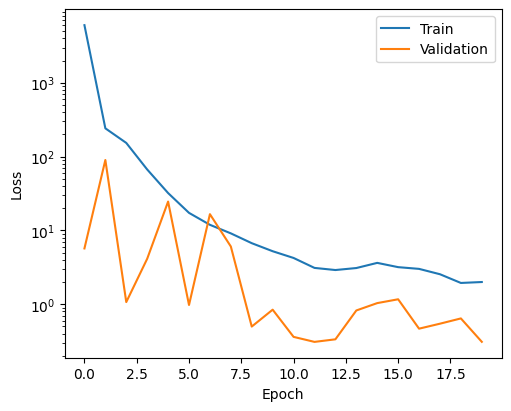

In [26]:
FINAL_EPOCHS = 20   # increase
print('Training final model with best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<22} {v}')
print(f'  {"epochs":<22} {FINAL_EPOCHS}\n')

core_net_final = TwoStreamNet(
    aev_dim=aev_dim,
    n_radial=n_radial,
    hidden_dim=best_params['hidden_dim'],
    n_residual=best_params['n_residual'],
    dropout=best_params['dropout'],
).to(device)

model_final = TwoStreamNetANI(aev_computer, core_net_final).to(device)

trainer_final = ANITrainer(
    model=model_final,
    batch_size=best_params['batch_size'],
    learning_rate=best_params['learning_rate'],
    epoch=FINAL_EPOCHS,
    l2=best_params['l2_weight_decay'],
    verbose=True,
)

train_losses, val_losses = trainer_final.train(
    train_data=training,
    val_data=validation,
    early_stop=True,
    draw_curve=True,
)

print(f'\nBest validation loss : {min(val_losses):.6e} Hartree\u00b2/atom')

###6.3 Tuned Evaluation Results

Run the following cell to evaluate the model trained within section 6.2:

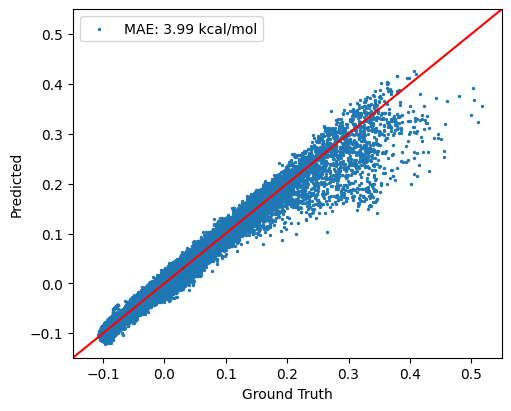

In [27]:
_ = trainer_final.evaluate(validation, draw_plot=True)

From the results above, it appears that the baysian hyperparameter tuning was a huge success. The aforementioned tuning strategy caused the model's best validation loss to halve, with a final MAE of ~2.785e-01 Hartree²/atom.

## 7 Multiple Training Runs

Training neural networks is stochastic. Even with identical hyperparameters and data, two runs can give different final losses because of:

1. Random weight initialization (Xavier uniform, as described in Section 4.4.1).
2. Mini-batch shuffling order.
3. Dropout masks sampled each forward pass.

Reporting a single run therefore understates real uncertainty. In this section I retrain the best configuration from Section 6 `N_RUNS` times with different random seeds on the *same* train / validation split, then report the distribution of final validation MAEs. This measures the training-stability component of the production-mode error bar.

### 7.1 MAE Helper

The existing `ANITrainer.evaluate` method only computes MAE (in kcal/mol) when it draws the parity plot. For multi-run and CV loops I need MAE *without* a plot on every call, so I define a small helper that evaluates the model once and returns total molecular MAE in kcal/mol. The conversion factor is 1 hartree = 627.5094738898777 kcal/mol.

In [15]:
HARTREE2KCALMOL = 627.5094738898777

def compute_metrics_kcalmol(model, data, batch_size=256):
    """Evaluate `model` on `data` and return error metrics in kcal/mol.

    Returns a dict with four metrics so the run can be compared against
    every reporting convention used in the ANI-1 paper:
      - 'rmse_total'    : RMSE on total molecular energy (kcal/mol).
                          Matches paper Sec. 3.4 train/val/test (1.2/1.3/1.3)
                          and Sec. 4 GDB-10 number (1.9).
      - 'rmse_per_atom' : RMSE on per-atom energy (kcal/mol/atom).
                          Matches paper ESI Table S1 (per-GDB-subset RMSE).
      - 'mae_total'     : MAE on total molecular energy (kcal/mol).
                          Kept for backward compatibility with earlier runs.
      - 'mae_per_atom'  : MAE on per-atom energy (kcal/mol/atom).
    """
    model.eval()
    loader = data.collate(batch_size).cache()

    total_err_chunks    = []
    per_atom_err_chunks = []
    with torch.no_grad():
        for batch in loader:
            species     = batch['species'].to(device)
            coordinates = batch['coordinates'].float().to(device)
            true_e      = batch['energies'].float().to(device)

            if species.dim() == 3:
                b1, b2, a = species.shape
                species = species.view(b1 * b2, a)
                coordinates = coordinates.view(b1 * b2, a, 3)
                true_e = true_e.view(b1 * b2)

            num_atoms   = (species >= 0).sum(dim=1, dtype=true_e.dtype)
            pred_e      = model((species, coordinates)).energies

            err_total    = (pred_e - true_e).detach().cpu().numpy()
            err_per_atom = ((pred_e - true_e) / num_atoms).detach().cpu().numpy()
            total_err_chunks.append(err_total)
            per_atom_err_chunks.append(err_per_atom)

    err_total    = np.concatenate(total_err_chunks)    * HARTREE2KCALMOL
    err_per_atom = np.concatenate(per_atom_err_chunks) * HARTREE2KCALMOL

    return {
        'rmse_total'    : float(np.sqrt((err_total    ** 2).mean())),
        'rmse_per_atom' : float(np.sqrt((err_per_atom ** 2).mean())),
        'mae_total'     : float(np.abs(err_total).mean()),
        'mae_per_atom'  : float(np.abs(err_per_atom).mean()),
    }


# Wrapper function to capture RMSE for comparison
def compute_mae_kcalmol(model, data, batch_size=256):
    return compute_metrics_kcalmol(model, data, batch_size)['mae_total']

### 7.2 Seeding Utility

To get truly different runs I seed Python, NumPy, and PyTorch (CPU + CUDA) before each run. This guarantees each run starts from a different weight initialization and sees a different mini-batch ordering, while keeping the overall experiment reproducible (same list of seeds => same list of final MAEs).

In [14]:
import random

def set_seed(seed: int):
    """Seed all RNGs so a training run is reproducible from `seed` alone."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

### 7.3 Multiple-Run Configuration

Use the cell below to adjust the number of independent runs and the number of epochs used per run. `PROD_EPOCHS` is set to match `FINAL_EPOCHS` from Section 6 so the multi-run estimate reflects the same training budget used to pick the final model.

In [ ]:
N_RUNS      = 5              # number of independent re-trainings
PROD_EPOCHS = 50   # epochs per run
RUN_SEEDS   = [42, 123, 6512, 7, 69694][:N_RUNS]

print(f'Will run {N_RUNS} independent re-trainings with seeds {RUN_SEEDS}.')

Will run 5 independent re-trainings with seeds [42, 123, 6512, 7, 69694].


### 7.4 Multiple-Run Loop

For each seed I re-initialize the model from scratch using the hyperparameters selected by Bayesian tuning in Section 5, train for `PROD_EPOCHS` with early stopping on the validation set, and then record the final validation MAE. GPU memory is freed between runs to prevent accumulation across the loop.

In [ ]:
multi_run_metrics    = []   # dicts of {rmse_total, rmse_per_atom, mae_total, mae_per_atom}
multi_run_train_loss = []
multi_run_val_loss   = []

for run_idx, seed in enumerate(RUN_SEEDS):
    print(f'\n===== Run {run_idx + 1}/{N_RUNS} | seed = {seed} =====')
    set_seed(seed)

    core_net_r = TwoStreamNet(
        aev_dim=aev_dim, n_radial=n_radial,
        hidden_dim=best_params['hidden_dim'],
        n_residual=best_params['n_residual'],
        dropout=best_params['dropout'],
    ).to(device)
    model_r = TwoStreamNetANI(aev_computer, core_net_r).to(device)

    trainer_r = ANITrainer(
        model=model_r,
        batch_size=best_params['batch_size'],
        learning_rate=best_params['learning_rate'],
        epoch=PROD_EPOCHS,
        l2=best_params['l2_weight_decay'],
        verbose=False,
    )

    tr_losses, va_losses = trainer_r.train(
        train_data=training, val_data=validation,
        early_stop=True, draw_curve=False,
    )

    metrics = compute_metrics_kcalmol(
        model_r, validation, batch_size=best_params['batch_size']
    )
    print(f"  RMSE total : {metrics['rmse_total']:.3f} kcal/mol "
          f"| RMSE/atom : {metrics['rmse_per_atom']:.3f} "
          f"| MAE total : {metrics['mae_total']:.3f}")

    multi_run_metrics.append(metrics)
    multi_run_train_loss.append(tr_losses)
    multi_run_val_loss.append(va_losses)

    del model_r, core_net_r, trainer_r
    torch.cuda.empty_cache()


===== Run 1/5 | seed = 42 =====


  0%|          | 0/50 [00:00<?, ?it/s]

  RMSE total : 5.711 kcal/mol | RMSE/atom : 0.777 | MAE total : 4.088

===== Run 2/5 | seed = 123 =====


  0%|          | 0/50 [00:00<?, ?it/s]

  RMSE total : 5.284 kcal/mol | RMSE/atom : 0.740 | MAE total : 3.699

===== Run 3/5 | seed = 6512 =====


...

  RMSE total : 5.587 kcal/mol | RMSE/atom : 0.765 | MAE total : 3.907

===== Run 4/5 | seed = 7 =====


  0%|          | 0/50 [00:00<?, ?it/s]

  RMSE total : 6.061 kcal/mol | RMSE/atom : 0.794 | MAE total : 4.310

===== Run 5/5 | seed = 69694 =====


  0%|          | 0/50 [00:00<?, ?it/s]

  RMSE total : 5.911 kcal/mol | RMSE/atom : 0.810 | MAE total : 4.171


### 7.5 Multiple-Run Results

Run the cell below to report the mean, standard deviation, and spread of validation MAE across all runs. A small standard deviation here means training is stable under seed changes and the hyperparameters chosen in Section 5 generalize beyond a single lucky initialization.

In [ ]:
rmse_arr = np.array([m['rmse_total']    for m in multi_run_metrics])
rpa_arr  = np.array([m['rmse_per_atom'] for m in multi_run_metrics])
mae_arr  = np.array([m['mae_total']     for m in multi_run_metrics])

print('Multi-Run Validation Metrics  (kcal/mol; RMSE/atom in kcal/mol/atom)')
print('-' * 72)
print(f"{'seed':>8} {'RMSE_total':>12} {'RMSE_/atom':>12} {'MAE_total':>12}")
for s, m in zip(RUN_SEEDS, multi_run_metrics):
    print(f"{s:>8} {m['rmse_total']:>12.3f} {m['rmse_per_atom']:>12.3f} "
          f"{m['mae_total']:>12.3f}")
print('-' * 72)
print(f"  RMSE_total      mean +/- std : {rmse_arr.mean():.3f} +/- {rmse_arr.std(ddof=1):.3f}")
print(f"  RMSE_per_atom   mean +/- std : {rpa_arr.mean():.3f} +/- {rpa_arr.std(ddof=1):.3f}")
print(f"  MAE_total       mean +/- std : {mae_arr.mean():.3f} +/- {mae_arr.std(ddof=1):.3f}")

# Keep these names alive for downstream cells (the existing plotting cell uses mae_arr).
mean_mae_mr = mae_arr.mean()
std_mae_mr  = mae_arr.std(ddof=1)

Multi-Run Validation Metrics  (kcal/mol; RMSE/atom in kcal/mol/atom)
------------------------------------------------------------------------
    seed   RMSE_total   RMSE_/atom    MAE_total
      42        5.711        0.777        4.088
     123        5.284        0.740        3.699
    6512        5.587        0.765        3.907
       7        6.061        0.794        4.310
   69694        5.911        0.810        4.171
------------------------------------------------------------------------
  RMSE_total      mean +/- std : 5.711 +/- 0.300
  RMSE_per_atom   mean +/- std : 0.777 +/- 0.027
  MAE_total       mean +/- std : 4.035 +/- 0.238


I also visualize the per-run MAE and the corresponding validation learning curves. The left panel shows the distribution of final MAEs as a scatter / error-bar plot; the right panel overlays the per-epoch validation loss from every run so I can check that the training dynamics (not just the final number) are consistent.

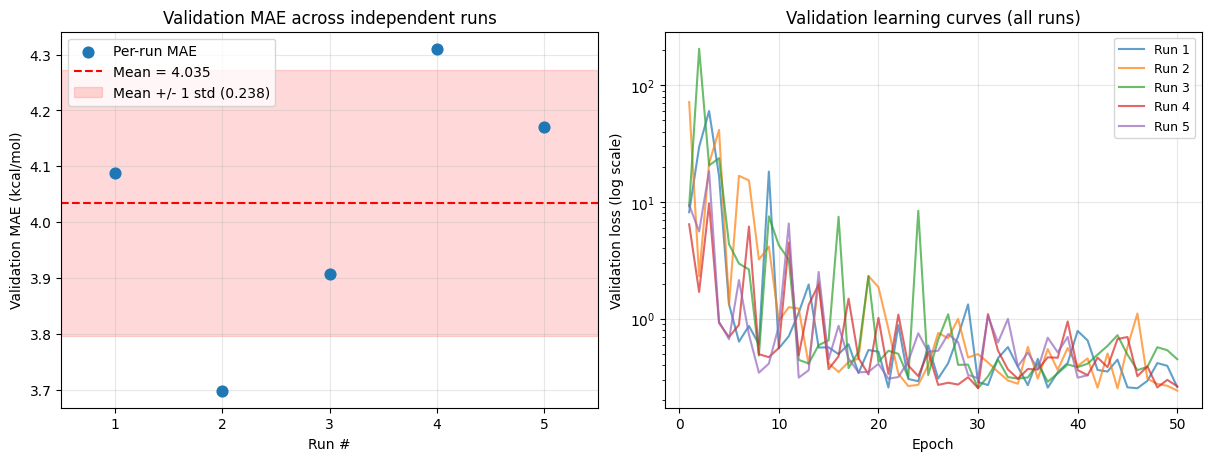

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: per-run MAE with mean +/- std band
axes[0].scatter(range(1, N_RUNS + 1), mae_arr, s=60, zorder=3, label='Per-run MAE')
axes[0].axhline(mean_mae_mr, color='red', linestyle='--', label=f'Mean = {mean_mae_mr:.3f}')
axes[0].fill_between(
    [0.5, N_RUNS + 0.5],
    mean_mae_mr - std_mae_mr, mean_mae_mr + std_mae_mr,
    color='red', alpha=0.15, label=f'Mean +/- 1 std ({std_mae_mr:.3f})'
)
axes[0].set_xticks(range(1, N_RUNS + 1))
axes[0].set_xlim(0.5, N_RUNS + 0.5)
axes[0].set_xlabel('Run #')
axes[0].set_ylabel('Validation MAE (kcal/mol)')
axes[0].set_title('Validation MAE across independent runs')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: validation loss curves, one per run
for i, vl in enumerate(multi_run_val_loss):
    axes[1].plot(range(1, len(vl) + 1), vl, alpha=0.7, label=f'Run {i + 1}')
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation loss (log scale)')
axes[1].set_title('Validation learning curves (all runs)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.show()

## 8 K-Fold Cross-Validation

The multi-run experiment in Section 7 quantifies variance from initialization and stochastic optimization, but it still uses a *single* train/validation split, so it cannot say how performance depends on *which* molecules were held out. K-fold cross-validation addresses this by partitioning the full dataset into `K_FOLDS` disjoint folds and, for each fold, training on the other `K_FOLDS - 1` folds and validating on the held-out fold. Averaging the held-out MAEs gives an (approximately) unbiased estimate of generalization error, and the spread across folds captures how sensitive the model is to the data split itself.

### 8.1 Concatenating Folds for Training

The existing `ANITrainer` expects an object that supports `.collate(batch_size).cache()`. A single fold returned by `dataset.split(...)` supports this, but the *union* of several folds does not, because `itertools.chain` strips away the method. The small helper below wraps `K_FOLDS - 1` folds and forwards `.collate(...).cache()` across them, which is all the trainer needs.

In [10]:
class ConcatFolds:
    """Expose a list of torchani dataset folds as a single trainable object.

    `ANITrainer.train` only calls `.collate(batch_size).cache()` and then
    iterates the result for each epoch, so we replicate that interface.
    Batches are yielded per fold in order; the last batch of each fold may
    be partial, which is acceptable for training.
    """
    def __init__(self, folds):
        self.folds = folds

    def collate(self, batch_size):
        return _ConcatCollated([f.collate(batch_size) for f in self.folds])


class _ConcatCollated:
    """Iterable of batches produced by ConcatFolds.collate(...)."""
    def __init__(self, batched_folds):
        self.batched_folds = batched_folds

    def cache(self):
        # Cache each underlying batched fold so multi-epoch iteration is cheap.
        return _ConcatCollated([bf.cache() for bf in self.batched_folds])

    def __iter__(self):
        for bf in self.batched_folds:
            yield from bf

### 8.2 Cross-Validation Configuration

Use the cell below to set the number of folds and the per-fold epoch budget. A 5-fold design is standard in the ML literature and gives each fold a 80/20 train/validation ratio that matches the split used for hyperparameter tuning in Section 5.

In [11]:
K_FOLDS  = 3                 # number of CV folds
CV_EPOCHS = 50     # epochs per fold
CV_SEED  = 2025              # seed for fold-construction reproducibility

print(f'Using K = {K_FOLDS} folds, {CV_EPOCHS} epochs per fold.')

Using K = 3 folds, 50 epochs per fold.


### 8.3 Building the Folds

The ANI-1 dataset was already loaded and shuffled in Section 5.2.1. Here I partition that same shuffled stream into `K_FOLDS` roughly equal pieces using `dataset.split(...)` with `K_FOLDS - 1` explicit fractions (the trailing `None` picks up the remainder). For each CV iteration one fold will be the validation set and the other `K_FOLDS - 1` are combined by `ConcatFolds` for training.

In [12]:
# Split the full shuffled dataset into K roughly-equal disjoint folds.
fold_fracs = [1.0 / K_FOLDS] * (K_FOLDS - 1)
folds      = list(dataset.split(*fold_fracs, None))

print(f'Dataset partitioned into {len(folds)} folds.')

Dataset partitioned into 3 folds.


### 8.4 Cross-Validation Loop

For each fold I **re-initialize the model** with the best hyperparameters from Section 5, train on the union of the other folds, and compute MAE on the held-out fold in kcal/mol. As in Section 7, I capture `trainer.train(...)` return values in variables so the per-epoch loss lists are not dumped to output, and GPU memory is freed between folds.

In [16]:
set_seed(CV_SEED)

cv_fold_metrics        = []    # held-out metrics (kcal/mol) per fold
cv_fold_train_loss = []    # per-fold training loss history
cv_fold_val_loss   = []    # per-fold validation loss history

for k in range(K_FOLDS):
    print(f'\n===== Fold {k + 1}/{K_FOLDS} =====')

    val_fold      = folds[k]
    train_folds_k = [folds[i] for i in range(K_FOLDS) if i != k]
    train_data_k  = ConcatFolds(train_folds_k)

    # Re-initialize a fresh model for this fold.
    core_net_k = TwoStreamNet(
        aev_dim    = aev_dim,
        n_radial   = n_radial,
        hidden_dim = best_params['hidden_dim'],
        n_residual = best_params['n_residual'],
        dropout    = best_params['dropout'],
    ).to(device)
    model_k = TwoStreamNetANI(aev_computer, core_net_k).to(device)

    trainer_k = ANITrainer(
        model         = model_k,
        batch_size    = best_params['batch_size'],
        learning_rate = best_params['learning_rate'],
        epoch         = CV_EPOCHS,
        l2            = best_params['l2_weight_decay'],
        verbose       = False,
    )

    tr_losses, va_losses = trainer_k.train(
        train_data = train_data_k,
        val_data   = val_fold,
        early_stop = True,
        draw_curve = False,
    )

    metrics = compute_metrics_kcalmol(
    model_k, val_fold, batch_size=best_params['batch_size'])
    print(f"  RMSE total: {metrics['rmse_total']:.3f}  "
          f"RMSE/atom: {metrics['rmse_per_atom']:.3f}  "
          f"MAE total: {metrics['mae_total']:.3f}  (kcal/mol)")

    cv_fold_metrics.append(metrics)        # rename cv_fold_mae -> cv_fold_metrics
    cv_fold_train_loss.append(tr_losses)
    cv_fold_val_loss.append(va_losses)

    del model_k, core_net_k, trainer_k
    torch.cuda.empty_cache()


===== Fold 1/3 =====


  0%|          | 0/50 [00:00<?, ?it/s]

  RMSE total: 6.237  RMSE/atom: 0.828  MAE total: 4.633  (kcal/mol)

===== Fold 2/3 =====


  0%|          | 0/50 [00:00<?, ?it/s]

  RMSE total: 5.680  RMSE/atom: 0.761  MAE total: 3.838  (kcal/mol)

===== Fold 3/3 =====


  0%|          | 0/50 [00:00<?, ?it/s]

  RMSE total: 6.092  RMSE/atom: 0.827  MAE total: 4.236  (kcal/mol)


### 8.5 Cross-Validation Results

The following cell displays the per-fold MAE and the mean +/- std summary. The mean is my production-mode estimate of generalization MAE for the `TwoStreamNet` model; the std is a first-order confidence interval on that estimate.

In [17]:
rmse_arr_cv = np.array([m['rmse_total']    for m in cv_fold_metrics])
rpa_arr_cv  = np.array([m['rmse_per_atom'] for m in cv_fold_metrics])
mae_arr_cv  = np.array([m['mae_total']     for m in cv_fold_metrics])


print(f'K-Fold Cross-Validation Results (K = {K_FOLDS})')
print('-' * 44)
for k, m in enumerate(mae_arr_cv):
    print(f'  Fold {k + 1}:  MAE = {m:.3f} kcal/mol')
print('-' * 44)
print(f"  RMSE_total      mean +/- std : {rmse_arr_cv.mean():.3f} +/- {rmse_arr_cv.std(ddof=1):.3f}")
print(f"  RMSE_per_atom   mean +/- std : {rpa_arr_cv.mean():.3f} +/- {rpa_arr_cv.std(ddof=1):.3f}")
print(f"  MAE_total       mean +/- std : {mae_arr_cv.mean():.3f} +/- {mae_arr_cv.std(ddof=1):.3f}")

mean_cv = mae_arr_cv.mean()
std_cv  = mae_arr_cv.std(ddof=1)

K-Fold Cross-Validation Results (K = 3)
--------------------------------------------
  Fold 1:  MAE = 4.633 kcal/mol
  Fold 2:  MAE = 3.838 kcal/mol
  Fold 3:  MAE = 4.236 kcal/mol
--------------------------------------------
  RMSE_total      mean +/- std : 6.003 +/- 0.289
  RMSE_per_atom   mean +/- std : 0.805 +/- 0.039
  MAE_total       mean +/- std : 4.236 +/- 0.397


I also wanted to visualize the per-fold MAE alongside the per-fold validation learning curves. Consistent curves across folds mean the model is not exploiting any peculiarity of a single split. Run the following cell to generate these visualizations:

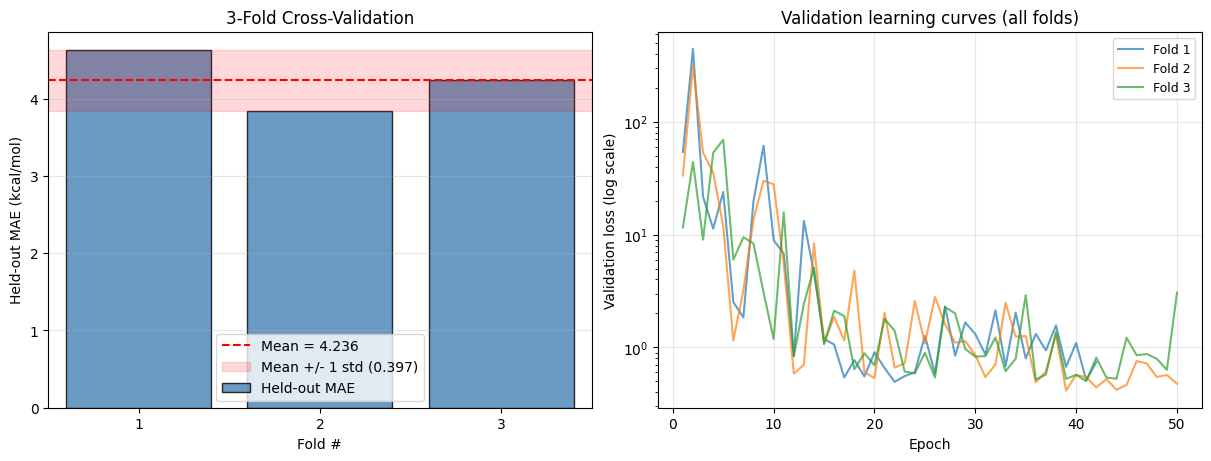

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# Left: per-fold bar chart with mean line
axes[0].bar(range(1, K_FOLDS + 1), mae_arr_cv, color='steelblue', alpha=0.8,
            edgecolor='black', label='Held-out MAE')
axes[0].axhline(mean_cv, color='red', linestyle='--',
                label=f'Mean = {mean_cv:.3f}')
axes[0].fill_between(
    [0.5, K_FOLDS + 0.5],
    mean_cv - std_cv, mean_cv + std_cv,
    color='red', alpha=0.15, label=f'Mean +/- 1 std ({std_cv:.3f})'
)
axes[0].set_xticks(range(1, K_FOLDS + 1))
axes[0].set_xlim(0.5, K_FOLDS + 0.5)
axes[0].set_xlabel('Fold #')
axes[0].set_ylabel('Held-out MAE (kcal/mol)')
axes[0].set_title(f'{K_FOLDS}-Fold Cross-Validation')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Right: validation loss curves, one per fold
for k, vl in enumerate(cv_fold_val_loss):
    axes[1].plot(range(1, len(vl) + 1), vl, alpha=0.7, label=f'Fold {k + 1}')
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation loss (log scale)')
axes[1].set_title('Validation learning curves (all folds)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.show()

## 9 Final Production Mode Results

Run the following cell to generate a performance summary for the final production-mode variant of my model.

In [21]:
print('=' * 60)
print('FINAL PERFORMANCE SUMMARY')
print('=' * 60)
print(f'Model              : TwoStreamNet (Section 3)')
print(f'Hyperparameters    : tuned in Section 5')
print(f'  learning_rate    : {best_params["learning_rate"]:.6g}')
print(f'  batch_size       : {best_params["batch_size"]}')
print(f'  l2_weight_decay  : {best_params["l2_weight_decay"]:.6g}')
print(f'  hidden_dim       : {best_params["hidden_dim"]}')
print(f'  n_residual       : {best_params["n_residual"]}')
print(f'  dropout          : {best_params["dropout"]:.4f}')
#print('-' * 60)
#print(f'Multi-Run Validation MAE  (N = {N_RUNS} seeds, same split)')
#print(f'  mean +/- std    : {mean_mae_mr:.3f} +/- {std_mae_mr:.3f}  kcal/mol')
#print(f'  range           : [{mae_arr.min():.3f}, {mae_arr.max():.3f}] kcal/mol')
print('-' * 60)
print(f'{K_FOLDS}-Fold Cross-Validation MAE  (disjoint held-out folds)')
print(f'  mean +/- std    : {mean_cv:.3f} +/- {std_cv:.3f}  kcal/mol')
print(f'  range           : [{mae_arr_cv.min():.3f}, {mae_arr_cv.max():.3f}] kcal/mol')
print('=' * 60)

FINAL PERFORMANCE SUMMARY
Model              : TwoStreamNet (Section 3)
Hyperparameters    : tuned in Section 5
  learning_rate    : 0.000406656
  batch_size       : 256
  l2_weight_decay  : 0.000122038
  hidden_dim       : 256
  n_residual       : 3
  dropout          : 0.1560
------------------------------------------------------------
3-Fold Cross-Validation MAE  (disjoint held-out folds)
  mean +/- std    : 4.236 +/- 0.397  kcal/mol
  range           : [3.838, 4.633] kcal/mol


##10 Model Comparison/Discussion

From the results of section 9 we see that ```TwoStreamNet``` achieves a held-out MAE of 4.236 +/- 0.397 kcal/mol, with a corresponding total-energy RMSE of 6.003 +/- 0.289 kcal/mol and a per-atom RMSE of 0.805 +/- 0.039 kcal/mol/atom under 3-fold cross-validation. The multi-run experiment in section 7 gives a tighter, single-split estimate of 4.035 +/- 0.238 kcal/mol MAE and 5.711 +/- 0.300 kcal/mol total-energy RMSE across 5 seeds. For context, ANI-1 reports a total-energy RMSE of 1.2, 1.3, and 1.3 kcal/mol on its training, validation, and test splits respectively, and a 1.8 kcal/mol RMSE on the held-out GDB-10 extensibility set. Comparing on the same metric (total-energy RMSE), ```TwoStreamNet``` sits roughly 4 to 5x above ANI-1.

Most of that gap is still attributable to training-set coverage. Although the section 5.2.1 pipeline now points at all eight shards, a file-extraction issue with s05 through s08 meant the actual training data fell back to the s01 through s04 subset, i.e. molecules with up to 4 heavy atoms only. ANI-1, by contrast, was trained on all of GDB s01 through s08 (~17.2 million conformations from ~57k molecules with up to 8 heavy atoms). As Smith et al. show in Fig. 4E of the ANI-1 paper, the GDB-10 extensibility RMSE drops sharply each time a larger heavy-atom subset is added to training, going from 26.0 kcal/mol with up to 4 heavy atoms down to 1.8 kcal/mol once 8-heavy-atom molecules are included, with the inclusion of 7-heavy-atom mono-substituted aromatics alone accounting for the largest single drop. In other words, the residual gap reflects a model that has only ever seen the smallest, least chemically diverse end of the ANI-1 distribution, so a meaningful portion of the difference is attributable to data coverage rather than to the model itself. Training-budget and loss-function choices contribute as well: ANI-1 trains until validation stops improving for 100 consecutive epochs and then repeats the optimization 6 times with an order of magnitude smaller learning rate each cycle, and it uses an exponential cost function the authors report yields 2 to 4x lower error than a standard squared loss, whereas ```TwoStreamNet``` trains for at most 50 epochs per run under per-atom MSE.

With those caveats in mind, I would argue that ```TwoStreamNet``` still presents a reasonable, more modern reformulation of the core ANI idea. Whereas ANI-1 maintains a separate pyramidal MLP (768:128:128:64:1) per element with Gaussian activations and max-norm regularization, ```TwoStreamNet``` uses a single shared network that splits the AEV into its radial and angular halves, processes each through its own stream, and fuses the two via a squeeze-and-excitation gate before a residual stack. The regularization choices justified in section 4 (LayerNorm before every CELU, Xavier-uniform initialization, dropout, L2 weight decay) and the Bayesian-tuned hyperparameters from section 5 give a principled starting point, and the production-mode estimate in section 9 is grounded in 3-fold cross-validation rather than a single split. Given the much smaller training domain and compute budget, I view 6.003 +/- 0.289 kcal/mol total-energy RMSE as a respectable starting point, and I expect that resolving the s05 through s08 loading issue, lengthening the training schedule, and adopting ANI-1's exponential cost function would close most of the remaining gap.